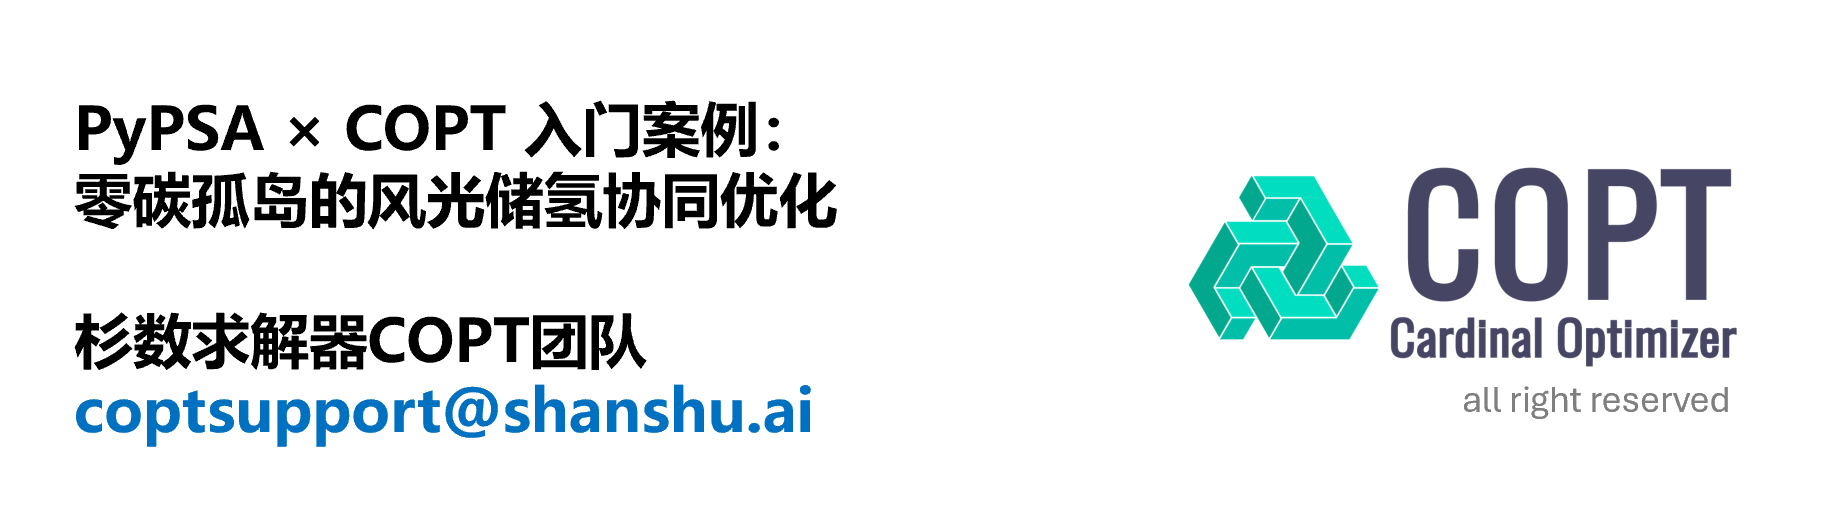

> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy pandas pypsa


In [ ]:
# 本案例需要数据文件；若已在 notebook 旁边则跳过下载
import os, urllib.parse, urllib.request
BASES = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/notebooks/zh/Powering_a_Zero_Carbon_Island_Co_optimizing_Wind_Solar_and_Hydrogen_Storage/',
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/zh/Powering_a_Zero_Carbon_Island_Co_optimizing_Wind_Solar_and_Hydrogen_Storage/',
]
FILES = [
    'costs_2030.csv',
    'time-series.csv',
]
for f in FILES:
    if os.path.exists(f):
        continue
    os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
    for b in BASES:
        try:
            urllib.request.urlretrieve(b + urllib.parse.quote(f), f)
            break
        except Exception:
            continue
missing = [f for f in FILES if not os.path.exists(f)]
print(len(FILES) - len(missing), '/', len(FILES), 'data file(s) ready')
if missing:
    print('NOT FETCHED:', missing)

# PyPSA × COPT 入门案例：零碳孤岛的风光储氢协同优化
> 本案例改编自 [PyPSA 官方示例：1-Node Capacity Expansion](https://docs.pypsa.org/latest/examples/capacity-expansion-planning-single-node/#wind-solar-and-load-time-series)，在原版基础上使用COPT求解器作为底层优化计算引擎。

## 导入COPT-Python接口库
导入PyPSA、coptpy及相关依赖库。

In [1]:
import pypsa
from pypsa.costs import annuity

import pandas as pd
import coptpy

Cardinal Optimizer v8.0.3. Build date Jan 13 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型数据
本案例数据来中，发电机组的成本数据源于PyPSA 官方维护的 [technology-data 仓库](https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{YEAR}.csv)，光照与风力强度数据则来源于柏林技术大学维护的数据库 [tubcloud](https://tubcloud.tu-berlin.de/s/9toBssWEdaLgHzq/download/time-series.csv)。其中：

- costs_2030.csv：包含了 2030 年各类发电设备和储能设备的预估成本（投资成本、运维成本、寿命等）；
- time-series.csv：包含了全年的风力发电效率、光伏发电效率以及电力需求的时间序列数据。

### 预估成本数据
我们计算两类成本：边际成本（每发一度电的变动成本，€/MWh）和年化资本成本（将一次性投资按折现率和寿命摊销到每年，€/MW/年）。
这里使用了一个小工具函数 `annuity`，根据折现率（discount rate）和设备寿命（lifetime）计算年金因子，从而将一次性投资折算为每年的成本。

In [2]:
# 获取成本数据
YEAR = 2030
costs = pd.read_csv(f"costs_{YEAR}.csv", index_col=[0, 1])
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs = costs.value.unstack().fillna({"discount rate": 0.07, "lifetime": 20, "FOM": 0})

# 计算边际成本
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

# 计算年化成本
a = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (a + costs["FOM"] / 100) * costs["investment"]

### 风能、太阳能和负荷时间序列数据
此处读取全年的风力发电效率、光伏发电效率以及电力需求的时间序列数据。这里我们将时间分辨率（RESOLUTION）设置为 3 小时。

In [3]:
# 风能、太阳能和负载时间序列
RESOLUTION = 3  # hours
ts = pd.read_csv("time-series.csv", index_col=0, parse_dates=True)[::RESOLUTION]
display(ts.head(3))

,load_mw,pv_pu,wind_pu
timestamp,,,
2019-01-01 00:00:00,5719.26,0.0,0.1846
2019-01-01 03:00:00,5474.74,0.0,0.3146
2019-01-01 06:00:00,5413.39,0.0,0.4957


## 初始化模型网络
初始化一个空的 PyPSA 网络，添加电力母线（Bus），并设置时间序列快照。

由于我们对时间序列进行了降采样（每3小时一个数据点），必须在 `n.snapshot_weightings` 中设置快照的权重（即每个快照代表多少小时），否则模型在计算年度总成本和总发电量时会出现误差。

In [4]:
n = pypsa.Network()
n.add("Bus", "electricity", carrier="electricity")
n.set_snapshots(ts.index)
# 每个时间步代表 3 小时，需要告知模型每个快照的时间权重
n.snapshot_weightings.loc[:, :] = RESOLUTION

### 添加能源载体（Carrier）分类
这一步仅用于后续绘图时区分颜色，不影响优化计算，并非强制要求。

In [5]:
# 设定能量类型
carriers = [
    "wind",
    "solar",
    "hydrogen storage",
    "battery storage",
    "load shedding",
    "electrolysis",
    "turbine",
    "electricity",
    "hydrogen",
]

# 设定不同能量对应颜色
colors = [
    "dodgerblue",
    "gold",
    "black",
    "yellowgreen",
    "darkorange",
    "magenta",
    "red",
    "grey",
    "pink",
]
n.add("Carrier", carriers, color=colors)

### 添加用电负荷
``p_set`` 参数传入全年逐时的实际用电量时间序列（单位：MW）。

In [6]:
n.add(
    "Load",
    "demand",
    bus="electricity",
    p_set=ts.load_mw,
)

### 添加发电机
添加风电和光伏发电机。与常规发电机不同，可再生能源发电机需要通过 `p_max_pu` 参数传入容量因子时间序列，它表示每个时刻该发电机的最大出力上限（相对于装机容量的比例）。`p_nom_extendable=True` 表示装机容量由优化模型自由决定。

此外，还添加一个虚拟负载发电机（Load Shedding），其边际成本设为 2000 €/MWh，用于模拟极端缺电情况下的“拉闸限电”代价。

In [7]:
# 风能
n.add(
    "Generator",
    "wind",
    bus="electricity",
    carrier="wind",
    p_max_pu=ts.wind_pu,
    capital_cost=costs.at["onwind", "capital_cost"],
    marginal_cost=costs.at["onwind", "marginal_cost"],
    p_nom_extendable=True,
)

# 太阳能
n.add(
    "Generator",
    "solar",
    bus="electricity",
    carrier="solar",
    p_max_pu=ts.pv_pu,
    capital_cost=costs.at["solar", "capital_cost"],
    marginal_cost=costs.at["solar", "marginal_cost"],
    p_nom_extendable=True,
)

# 添加负载发电机，模拟停电时的高成本
n.add(
    "Generator",
    "load shedding",
    bus="electricity",
    carrier="load shedding",
    marginal_cost=2000,
    p_nom=ts.load_mw.max(),
)

### 添加电池储能元件
电池的投资成本由两部分组成：逆变器（功率成本）和电池本体（容量成本），这里假设电池的最大连续放电时间为 3 小时 (`max_hours=3`)。

In [8]:
# 电池储能
n.add(
    "StorageUnit",
    "battery storage",
    bus="electricity",
    carrier="battery storage",
    max_hours=3,
    capital_cost=costs.at["battery inverter", "capital_cost"]
    + 3 * costs.at["battery storage", "capital_cost"],
    efficiency_store=costs.at["battery inverter", "efficiency"],
    efficiency_dispatch=costs.at["battery inverter", "efficiency"],
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

### 添加氢气存储系统
添加一个氢气储能系统。该系统由三个组件协同构成：电解槽（将多余电能转化为氢气）、氢气涡轮机（将氢气转化回电能）和地下储氢罐。这三个组件的容量均可由模型灵活优化。

#### 添加链接组件（电解槽和氢气涡轮机）实现氢气与电力的互相转换

In [9]:
n.add("Bus", "hydrogen", carrier="hydrogen")

n.add(
    "Link",
    "electrolysis",
    bus0="electricity",
    bus1="hydrogen",
    carrier="electrolysis",
    p_nom_extendable=True,
    efficiency=costs.at["electrolysis", "efficiency"],
    capital_cost=costs.at["electrolysis", "capital_cost"],
)

n.add(
    "Link",
    "turbine",
    bus0="hydrogen",
    bus1="electricity",
    carrier="turbine",
    p_nom_extendable=True,
    efficiency=costs.at["OCGT", "efficiency"],
    capital_cost=costs.at["OCGT", "capital_cost"] / costs.at["OCGT", "efficiency"],
)

#### 添加氢气存储组件（地下储氢罐）

In [10]:
n.add(
    "Store",
    "hydrogen storage",
    bus="hydrogen",
    carrier="hydrogen storage",
    capital_cost=costs.at["hydrogen storage underground", "capital_cost"],
    e_nom_extendable=True,
    e_cyclic=True,
)

## 求解
PyPSA支持多种求解器，默认使用开源的HiGHS求解器。此处，我们将 ``solver_name`` 参数设置为 ``"copt"``，PyPSA 就会自动在底层调用COPT求解器来处理这个复杂的线性规划问题。COPT 在处理此类大规模能源优化问题时具有高效的求解效率。运行前请确保已安装COPT的Python接口，并完成COPT的License配置，可参考：[COPT用户手册](https://guide.coap.online/copt/zh-doc/)。

In [11]:
# 设定求解器为 COPT 求解器
pypsa.options.params.optimize.solver_name = "copt"
n.optimize()

C:\Users\chent\AppData\Local\Temp\ipykernel_22428\2991699393.py:3: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Copt solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 435.35it/s]
INFO:linopy.io: Writing time: 0.25s


Cardinal Optimizer v8.0.3. Build date Jan 13 2026
Copyright Cardinal Operations 2026. All Rights Reserved

Reading from 'C:\Users\chent\AppData\Local\Temp\linopy-problem-omqxgnz_.lp'
Reading finished (0.06s)
Model fingerprint: 57eea178

Using Cardinal Optimizer v8.0.3 on Windows (25H2 Build 26200 - x86_64)
The CPU model is 13th Gen Intel(R) Core(TM) i5-13500H
Hardware has 12 physical cores and 16 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an LP problem

The original problem has:
    64246 rows, 29206 columns and 124144 non-zero elements
The presolved problem has:
    30698 rows, 24864 columns and 86254 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [1e-01,8e+00]
    Range of rhs coefficients:       [6e+03,4e+04]
    Range of bound coefficients:     [1e+04,4e+04]
    Range of cost coefficients:      [4e+02,5e+05]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual  

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 29206 primals, 64246 duals
Objective: 1.01e+10
Solver model: available
Solver message: 1

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

## 获取结果
### 获取各种发电措施各自成本
各发电措施的年化总成本（资本支出 + 运营支出之和），单位：十亿欧元（GEur）。

In [12]:
tsc = (
    pd.concat([n.statistics.capex(), n.statistics.opex()], axis=1).sum(axis=1).div(1e9)
)

tsc

component    carrier         
Generator    solar               1.684343
             wind                4.180646
Link         electrolysis        0.739954
             turbine             1.424007
StorageUnit  battery storage     1.124633
Store        hydrogen storage    0.688179
Generator    load shedding       0.290825
dtype: float64

### 获取整个发电系统总成本

In [13]:
tsc.sum()

np.float64(10.13258693337858)

### 获取各种发电措施最优投入量
单位：GW（储能 `Store` 组件单位为 GWh）：

In [14]:
n.statistics.optimal_capacity().div(1e3)

component    carrier         
Generator    load shedding         10.901160
             solar                 26.089521
             wind                  32.583318
Link         electrolysis           3.118498
             turbine                9.692634
StorageUnit  battery storage       14.047947
Store        hydrogen storage    3672.190855
dtype: float64

### 获取各发电措施全年累计发电量或消耗电量

电力侧的全年能量平衡，单位：TWh。正值为供电，负值为用电或充电：

In [15]:
n.statistics.energy_balance(bus_carrier="electricity").sort_values().div(1e6)

component    carrier          bus_carrier
Load         -                electricity   -66.266089
Link         electrolysis     electricity   -15.656979
StorageUnit  battery storage  electricity    -0.732725
Generator    load shedding    electricity     0.145412
Link         turbine          electricity     3.990917
Generator    solar            electricity    26.667456
             wind             electricity    51.852008
dtype: float64

### 全年电力平衡图

图中正值区域（蓝色、金色）代表风电和光伏的发电量；负值区域代表用电负荷和储能充电。可以观察到：夏季光伏出力明显高于冬季；在风光资源充足的时段，多余的电能被储入电池或转化为氢气；橙色区域（load shedding，拉闸限电）出现的时刻，说明系统在当前成本参数下，选择了"限电"而非"扩容"。

(<Figure size 758.25x300 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance []'>,
 <seaborn.axisgrid.FacetGrid at 0x268028852b0>)

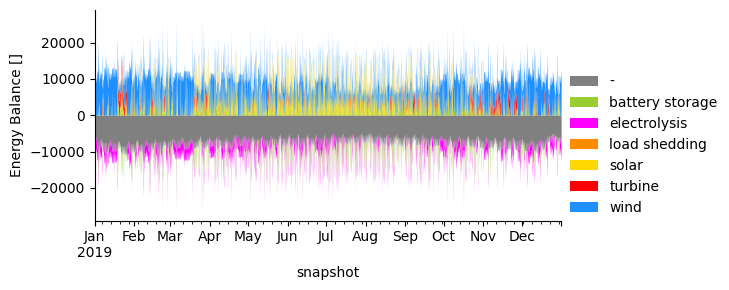

In [16]:
n.statistics.energy_balance.plot.area(linewidth=0, bus_carrier="electricity")

### 边际价格图
电力的边际价格（蓝线）在绝大多数时间接近于零，这意味着风光发电量充裕，系统几乎没有额外供电成本。当价格出现尖峰（接近 2000 元/MWh）时，说明系统正在调用虚拟负载发电机（load shedding），此时的高价格反映了断电的经济损失。氢气的边际价格（橙线）整体平稳且较低，体现了氢气作为长期储能介质的低成本特性。

<Axes: xlabel='snapshot'>

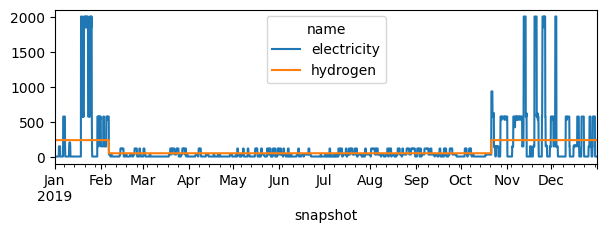

In [17]:
n.buses_t.marginal_price.plot(figsize=(7, 2))